<a href="https://colab.research.google.com/github/m-ramaz/machine-learning-practice/blob/main/Outliers_in_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **How to Detect outliers **

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# now importing dataset
df=pd.read_csv("/content/placement.csv")
df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


In [8]:
df.shape   # check rows and column

(1000, 3)

In [9]:
df.describe()  # give five number summary

,cgpa,placement_exam_marks,placed
count,1000.000000,1000.000000,1000.000000
mean,6.961240,32.225000,0.489000
std,0.615898,19.130822,0.500129
min,4.890000,0.000000,0.000000
25%,6.550000,17.000000,0.000000
50%,6.960000,28.000000,0.000000
75%,7.370000,44.000000,1.000000
max,9.120000,100.000000,1.000000


/tmp/ipykernel_2071/3792736820.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['cgpa'])
/tmp/ipykernel_2071/3792736820.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])


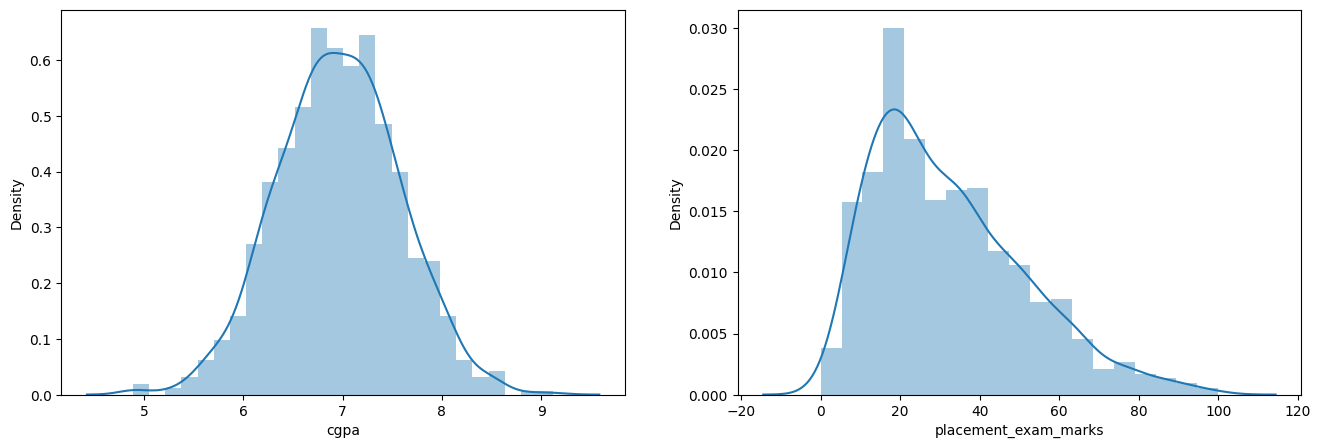

In [10]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(df['cgpa'])

plt.subplot(1,2,2)
sns.distplot(df['placement_exam_marks'])

plt.show()

In [11]:
df['placement_exam_marks'].skew()    # data positively skewed hai kuch high values majood hain, right side tail lambi hai

np.float64(0.8356419499466834)

<Axes: xlabel='placement_exam_marks', ylabel='Count'>

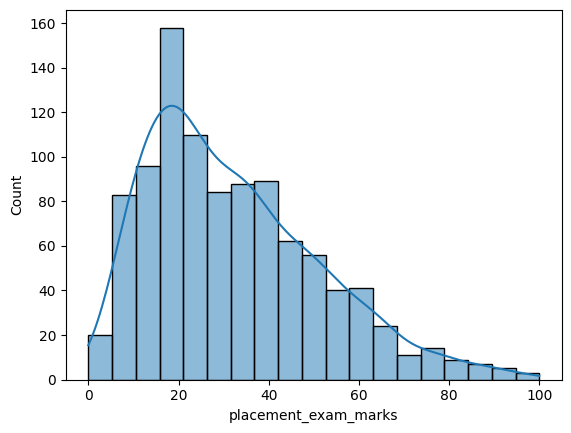

In [12]:
sns.histplot(df['placement_exam_marks'], kde=True)

In [13]:
# null values dekhny ke lye pory dataframe ke har colum ki
df.isnull().sum()    # yahan sb ki sb values majood hain.

,0
cgpa,0
placement_exam_marks,0
placed,0


**# since cgpa column is normally distribute we can use z score / percentage method to identify outliers**

In [14]:
print("Mean of cgpa is:",df['cgpa'].mean())
print("Standard deviation of cgpa is:",df['cgpa'].std())
print("Minimum value of cgpa is: ",df['cgpa'].min())
print("Maximum value of cgpa is: ",df['cgpa'].max())

Mean of cgpa is: 6.96124
Standard deviation of cgpa is: 0.6158978751323894
Minimum value of cgpa is:  4.89
Maximum value of cgpa is:  9.12


In [15]:
#find boundary values
print("Highest value allowed:",df['cgpa'].mean()+3*df['cgpa'].std())
print("Lowest value allowed:",df['cgpa'].mean()-3*df['cgpa'].std())

Highest value allowed: 8.808933625397168
Lowest value allowed: 5.113546374602832


In [23]:
upper_limit=df['cgpa'].mean()+3*df['cgpa'].std()
lower_limit=df['cgpa'].mean()-3*df['cgpa'].std()


In [24]:
upper_limit

np.float64(8.808933625397168)

**Now we will check that if these rows are higher than we will capped them and if not then we drop them**

In [16]:
df[(df['cgpa']>8.80) | (df['cgpa']<5.11)].shape

(5, 3)

In [17]:
df_new=df[(df['cgpa']<8.80) & (df['cgpa']>5.11)] # df_new=df[conditon]
df_new

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


In [18]:
df_new.describe()

,cgpa,placement_exam_marks,placed
count,995.000000,995.000000,995.000000
mean,6.963357,32.188945,0.487437
std,0.600082,19.130298,0.500094
min,5.230000,0.000000,0.000000
25%,6.550000,17.000000,0.000000
50%,6.960000,28.000000,0.000000
75%,7.365000,44.000000,1.000000
max,8.620000,100.000000,1.000000


**Second approach**

In [19]:
# z-score
from scipy.stats import zscore

In [20]:
df['z_score']=zscore(df['cgpa'])

In [21]:
df

,cgpa,placement_exam_marks,placed,z_score
0,7.19,26.0,1,0.371611
1,7.46,38.0,1,0.810215
2,7.54,40.0,1,0.940171
3,6.42,8.0,1,-0.879222
4,7.23,17.0,0,0.436589
...,...,...,...,...
995,8.87,44.0,1,3.100701
996,9.12,65.0,1,3.506815
997,4.89,34.0,0,-3.364643
998,8.62,46.0,1,2.694586


In [22]:
new_sec_df=df[(df['z_score']<3) & (df['z_score']>-3)]
new_sec_df

,cgpa,placement_exam_marks,placed,z_score
0,7.19,26.0,1,0.371611
1,7.46,38.0,1,0.810215
2,7.54,40.0,1,0.940171
3,6.42,8.0,1,-0.879222
4,7.23,17.0,0,0.436589
...,...,...,...,...
991,7.04,57.0,0,0.127942
992,6.26,12.0,0,-1.139135
993,6.73,21.0,1,-0.375640
994,6.48,63.0,0,-0.781754


**Capping**

In [25]:
df['cgpa']=np.where(
    df['cgpa']>upper_limit,
    upper_limit,
    np.where(
        df['cgpa']<lower_limit,
        lower_limit,
        df['cgpa']
    )
)

In [26]:
df.describe()  #yahan outliers khtm ho gaye hain

,cgpa,placement_exam_marks,placed,z_score
count,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,6.961499,32.225000,0.489000,-1.465494e-16
std,0.612688,19.130822,0.500129,1.000500e+00
min,5.113546,0.000000,0.000000,-3.364643e+00
25%,6.550000,17.000000,0.000000,-6.680422e-01
50%,6.960000,28.000000,0.000000,-2.014328e-03
75%,7.370000,44.000000,1.000000,6.640135e-01
max,8.808934,100.000000,1.000000,3.506815e+00
